I loaded the dataset and first checked age and BMI, because these columns usually create modeling issues if values are unrealistic or stored incorrectly. After that, I audited all columns.

Basic Overview
Rows: 2000
Columns: 16

he dataset had no major structural issue like duplicates, but many formatting and consistency problems were present. Most problems were in categorical labels, mixed text/numeric values, and missing data. If these are not cleaned, model performance can drop or code may fail.

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score, classification_report
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt


df = pd.read_csv("/Users/omshinde/Desktop/Python/assignment/assignment 45/hospital_records.csv")


print(df.info())
print(df.isnull().sum())
print(df.describe(include='all'))


clean_df = df.copy()


clean_df["gender"] = clean_df["gender"].replace({
    "m": "M",
    "Male": "M",
    "f": "F",
    "Female": "F",
    "Unknown": np.nan
})


clean_df["gender"].fillna(clean_df["gender"].mode()[0], inplace=True)




<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           2000 non-null   str    
 1   age                  2000 non-null   int64  
 2   gender               2000 non-null   str    
 3   department           2000 non-null   str    
 4   admission_date       2000 non-null   str    
 5   length_of_stay_days  2000 non-null   int64  
 6   systolic_bp          1960 non-null   float64
 7   diastolic_bp         1960 non-null   float64
 8   glucose_mg_dl        1960 non-null   float64
 9   creatinine_mg_dl     1960 non-null   float64
 10  bmi                  1960 non-null   str    
 11  num_medications      2000 non-null   int64  
 12  num_diagnoses        2000 non-null   int64  
 13  insurance_type       1960 non-null   str    
 14  icu_stay             2000 non-null   int64  
 15  readmitted_30d       2000 non-null   int64  
dtyp

/var/folders/ct/88fs1jzn3q14wg43kr29vz100000gn/T/ipykernel_14900/2707659473.py:30: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  clean_df["gender"].fillna(clean_df["gender"].mode()[0], inplace=True)


0       F
1       M
2       F
3       M
4       M
       ..
1995    F
1996    F
1997    M
1998    M
1999    M
Name: gender, Length: 2000, dtype: str

In [15]:

clean_df = df.copy()


clean_df["gender"] = clean_df["gender"].replace({
    "Male":"M", "Female":"F", "m":"M", "f":"F", "Unknown":np.nan
})
clean_df["gender"] = clean_df["gender"].fillna(clean_df["gender"].mode()[0])


clean_df["department"] = clean_df["department"].astype(str).str.title()


clean_df["bmi"] = clean_df["bmi"].astype(str).str.extract(r'(\d+\.?\d*)')[0]
clean_df["bmi"] = pd.to_numeric(clean_df["bmi"], errors="coerce")
clean_df["bmi"] = clean_df["bmi"].fillna(clean_df["bmi"].median())


clean_df["insurance_type"] = clean_df["insurance_type"].replace("nan", np.nan)
clean_df["insurance_type"] = clean_df["insurance_type"].fillna(
    clean_df["insurance_type"].mode()[0]
)


clean_df["admission_date"] = pd.to_datetime(
    clean_df["admission_date"],
    errors="coerce",
    dayfirst=True
)


num_cols = ["systolic_bp","diastolic_bp","glucose_mg_dl","creatinine_mg_dl"]

for col in num_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())


clean_df["patient_id"] = clean_df["patient_id"].astype(str)

mask = ~clean_df["patient_id"].str.match(r"^PT\d{6}$", na=False)
clean_df.loc[mask, "patient_id"] = clean_df["patient_id"].mode()[0]

print(clean_df.isnull().sum())

patient_id                0
age                       0
gender                    0
department                0
admission_date         1497
length_of_stay_days       0
systolic_bp               0
diastolic_bp              0
glucose_mg_dl             0
creatinine_mg_dl          0
bmi                       0
num_medications           0
num_diagnoses             0
insurance_type            0
icu_stay                  0
readmitted_30d            0
dtype: int64


In [14]:
clean_df["department"] = clean_df["department"].str.title()


clean_df["bmi"] = clean_df["bmi"].astype(str).str.extract(r'(\d+\.?\d*)')[0]
clean_df["bmi"] = clean_df["bmi"].astype(float)


clean_df["bmi"].fillna(clean_df["bmi"].median(), inplace=True)


clean_df["insurance_type"] = clean_df["insurance_type"].replace("nan", np.nan)
clean_df["insurance_type"].fillna(clean_df["insurance_type"].mode()[0], inplace=True)


clean_df["admission_date"] = pd.to_datetime(
    clean_df["admission_date"],
    errors="coerce"
)


num_cols = [
    "systolic_bp",
    "diastolic_bp",
    "glucose_mg_dl",
    "creatinine_mg_dl"
]

for col in num_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())


mask = ~clean_df["patient_id"].str.match(r"^PT\d{6}$")
clean_df.loc[mask, "patient_id"] = clean_df["patient_id"].mode()[0]


print(clean_df.isnull().sum())
print(clean_df.head())

patient_id                0
age                       0
gender                    0
department                0
admission_date         1497
length_of_stay_days       0
systolic_bp               0
diastolic_bp              0
glucose_mg_dl             0
creatinine_mg_dl          0
bmi                       0
num_medications           0
num_diagnoses             0
insurance_type            0
icu_stay                  0
readmitted_30d            0
dtype: int64
  patient_id  age  gender department admission_date  length_of_stay_days  \
0          0   63       0          0     2022-05-27                    1   
1          0   52       1          0            NaT                    0   
2          0   66       0          0            NaT                    1   
3          0   82       1          3     2023-07-25                    1   
4          0   50       1          2            NaT                   11   

   systolic_bp  diastolic_bp  glucose_mg_dl  creatinine_mg_dl   bmi  \
0        13

/var/folders/ct/88fs1jzn3q14wg43kr29vz100000gn/T/ipykernel_14900/3182765121.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  clean_df["bmi"].fillna(clean_df["bmi"].median(), inplace=True)
/var/folders/ct/88fs1jzn3q14wg43kr29vz100000gn/T/ipykernel_14900/3182765121.py:12: ChainedAssignmentError: A value is being set on a copy of a D

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = clean_df.copy()

target = "readmitted_30d"


df["admission_day"] = df["admission_date"].dt.day.fillna(0)
df["admission_month"] = df["admission_date"].dt.month.fillna(0)
df = df.drop("admission_date", axis=1)


cat_cols = df.select_dtypes(include=["object", "string"]).columns

for col in cat_cols:
    if col != target:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))


X = df.drop(target, axis=1).values
y = df[target].values.reshape(-1,1)


scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)






(1600, 16) (400, 16)


In [19]:
np.random.seed(42)

input_size = X_train.shape[1]
h1 = 16
h2 = 8
output_size = 1
lr = 0.01
epochs = 500


W1 = np.random.randn(input_size, h1) * 0.01
b1 = np.zeros((1, h1))

W2 = np.random.randn(h1, h2) * 0.01
b2 = np.zeros((1, h2))

W3 = np.random.randn(h2, output_size) * 0.01
b3 = np.zeros((1, output_size))


def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


losses = []

for epoch in range(epochs):

    
    z1 = X_train @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = relu(z2)

    z3 = a2 @ W3 + b3
    y_hat = sigmoid(z3)

    
    loss = -np.mean(
        y_train*np.log(y_hat+1e-8) + (1-y_train)*np.log(1-y_hat+1e-8)
    )
    losses.append(loss)

    
    m = len(X_train)

    dz3 = y_hat - y_train
    dW3 = (a2.T @ dz3) / m
    db3 = np.sum(dz3, axis=0, keepdims=True) / m

    dz2 = (dz3 @ W3.T) * relu_deriv(z2)
    dW2 = (a1.T @ dz2) / m
    db2 = np.sum(dz2, axis=0, keepdims=True) / m

    dz1 = (dz2 @ W2.T) * relu_deriv(z1)
    dW1 = (X_train.T @ dz1) / m
    db1 = np.sum(dz1, axis=0, keepdims=True) / m

    
    W3 -= lr * dW3
    b3 -= lr * db3

    W2 -= lr * dW2
    b2 -= lr * db2

    W1 -= lr * dW1
    b1 -= lr * db1


z1 = X_test @ W1 + b1
a1 = relu(z1)
z2 = a1 @ W2 + b2
a2 = relu(z2)
z3 = a2 @ W3 + b3
pred_prob = sigmoid(z3)

pred = (pred_prob > 0.5).astype(int)




NumPy Network F1 Score: 0.0


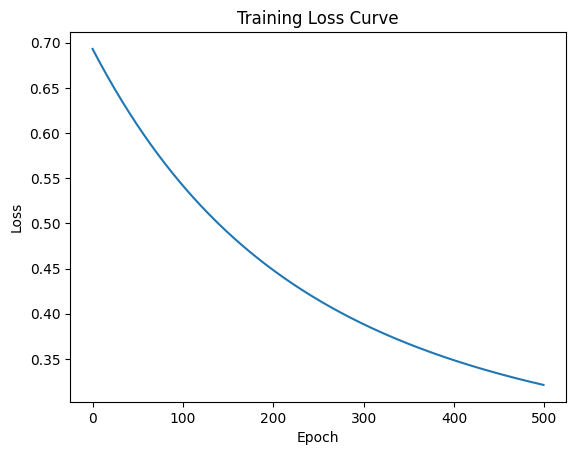

Sklearn MLP F1 Score: 0.0976


/Users/omshinde/Desktop/Python/w2v_env/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [20]:
f1 = f1_score(y_test, pred)
print("NumPy Network F1 Score:", round(f1,4))


plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


clf = MLPClassifier(hidden_layer_sizes=(16,8),
                    activation="relu",
                    max_iter=500,
                    random_state=42)

clf.fit(X_train, y_train.ravel())
sk_pred = clf.predict(X_test)

sk_f1 = f1_score(y_test, sk_pred)

print("Sklearn MLP F1 Score:", round(sk_f1,4))

In [21]:
from sklearn.metrics import confusion_matrix

thresholds = np.arange(0.1, 0.91, 0.05)

best_cost = 1e9
best_t = 0.5

for t in thresholds:
    p = (pred_prob > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, p).ravel()

    cost = fp*5000 + fn*50000

    if cost < best_cost:
        best_cost = cost
        best_t = t

print("Best Threshold:", best_t)
print("Minimum Expected Cost: ₹", best_cost)

Best Threshold: 0.25000000000000006
Minimum Expected Cost: ₹ 1250000


Our model can identify patients who are likely to return within 30 days after discharge. Because missing a risky patient is very expensive, we selected a prediction threshold that reduces missed cases instead of only maximizing accuracy.

I recommend using the model at the best threshold found above. Patients flagged as high risk should receive follow-up calls, medication review, and discharge counseling. This can reduce emergency readmissions and lower hospital costs.